# 04 — `valenbisi`: ocupación de las estaciones de bici pública

**Origen.** ArcGIS REST del geoportal del Ajuntament, capa `OPENDATA/Valenbisi/228`.
Sondeo cada 5 minutos.

**Papel en el TFM.** Covariable de contexto, no núcleo. La ocupación de las
estaciones es un proxy barato de actividad urbana: si una zona vacía sus anclajes
a las 8:00, ahí hay demanda de movilidad, y eso puede correlacionar con
congestión. EDA estándar, sin la profundidad de los notebooks 01 y 02.

In [1]:
import sys
from pathlib import Path

# El notebook debe correr tanto abierto desde notebooks/EDA como ejecutado
# desde la raíz del repo (nbclient, CI).
AQUI = Path("notebooks/EDA").resolve() if Path("notebooks/EDA").exists() else Path.cwd()
sys.path.insert(0, str(AQUI))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import eda_utils as eu

eu.estilo()
FUENTE = "valenbisi"
print("corpus:", eu.dir_fuente(FUENTE))

corpus: C:\Users\oppen\Code\TFM\data\curated\source=valenbisi


## 1. Censo y esquema

In [2]:
eu.censo(FUENTE)

,valor
métrica,
fuente,valenbisi
filas,"1,148,238"
ficheros parquet,682
particiones (días),17
tamaño en disco,25.7 MB
ts_utc mínimo,2026-07-20 07:33:55+00:00
ts_utc máximo,2026-08-31 16:32:37+00:00


In [3]:
eu.esquema(FUENTE)

,columna,tipo
0,number,BIGINT
1,name,VARCHAR
2,address,VARCHAR
3,abierta,BOOLEAN
4,available,BIGINT
5,free,BIGINT
6,total,BIGINT
7,lat,DOUBLE
8,lon,DOUBLE
9,ts_utc,TIMESTAMP WITH TIME ZONE


## 2. Calidad

In [4]:
eu.perfil_nulos(FUENTE)

,columna,nulos,pct_nulos,distintos,constante
0,number,0,0.000,273,False
1,name,0,0.000,273,False
2,address,0,0.000,273,False
3,abierta,0,0.000,1,True
4,available,0,0.000,41,False
5,free,0,0.000,41,False
6,total,0,0.000,22,False
7,lat,0,0.000,273,False
8,lon,0,0.000,273,False
9,ts_utc,0,0.000,444209,False


In [5]:
eu.duplicados(FUENTE, ["ts_ingest_utc", "number"])

,filas,combinaciones_unicas,duplicadas
0,1148238,1148238,0


## 3. Coherencia interna: ¿`available + free == total`?

Es la comprobación obvia y la que más dice sobre si la fuente se puede creer.

In [6]:
coh = eu.sql(
    """
    SELECT count(*) AS filas,
           sum(CASE WHEN available + free = total THEN 1 ELSE 0 END) AS cuadra,
           sum(CASE WHEN available + free <> total THEN 1 ELSE 0 END) AS no_cuadra,
           median(available + free - total) AS desfase_mediano,
           min(available + free - total) AS desfase_min,
           max(available + free - total) AS desfase_max
    FROM {f}
    """,
    f=FUENTE,
)
coh["pct_no_cuadra"] = 100 * coh["no_cuadra"] / coh["filas"]
coh.round(2)

,filas,cuadra,no_cuadra,desfase_mediano,desfase_min,desfase_max,pct_no_cuadra
0,1148238,"861,899.000","286,339.000",0.000,-30,3,24.940


In [7]:
desf = eu.sql(
    """
    SELECT available + free - total AS desfase, count(*) AS filas
    FROM {f} GROUP BY 1 ORDER BY 2 DESC LIMIT 15
    """,
    f=FUENTE,
)
desf

,desfase,filas
0,0,861899
1,-1,180568
2,-2,54276
3,-3,19507
4,-4,6483
5,-20,5355
6,-5,4378
7,-17,4210
8,-24,4206
9,-11,3812


count   273.000
mean     24.900
std      30.000
min       0.000
25%       2.200
50%      14.700
75%      35.200
max     100.000


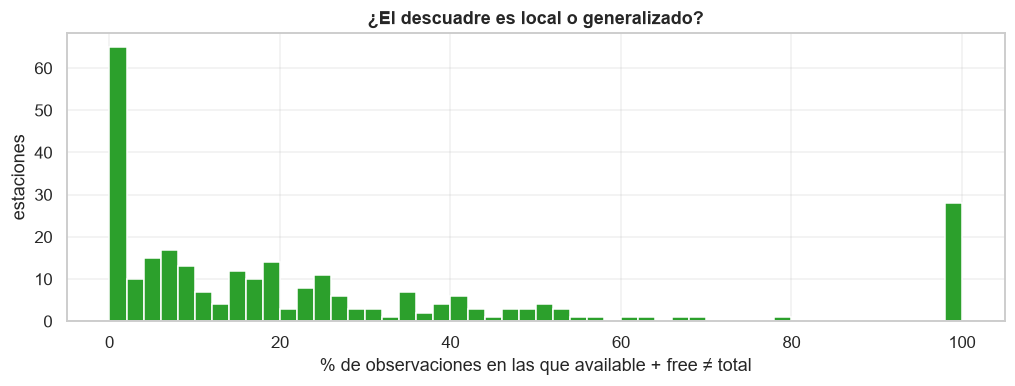

In [8]:
# ¿El descuadre es de unas pocas estaciones averiadas o está repartido?
por_est = eu.sql(
    """
    SELECT number, any_value(name) AS nombre, count(*) AS obs,
           100.0 * sum(CASE WHEN available + free <> total THEN 1 ELSE 0 END) / count(*) AS pct_descuadre
    FROM {f} GROUP BY 1
    """,
    f=FUENTE,
)
print(por_est["pct_descuadre"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(por_est["pct_descuadre"], bins=50, color=eu.PALETA[FUENTE])
ax.set_xlabel("% de observaciones en las que available + free ≠ total")
ax.set_ylabel("estaciones")
ax.set_title("¿El descuadre es local o generalizado?")
plt.show()

**El descuadre está repartido, no concentrado.** No hay dos grupos de estaciones
—unas sanas y otras averiadas—: la mediana ronda el 15 % de observaciones
descuadradas por estación, con una cola que llega al 100 %. Excluir estaciones no
arregla nada.

Y el desfase es **casi siempre negativo**: `available + free` se queda por debajo
de `total`, nunca por encima salvo excepciones mínimas. Eso identifica qué es cada
campo: **`total` es la capacidad física instalada de la estación**, y
`available + free` los anclajes que están operativos en ese momento. Los que
faltan son anclajes averiados o bicis en mantenimiento.

Consecuencia directa para `features.py`: la ocupación se calcula como
`available / (available + free)`. Usar `total` como denominador introduce un sesgo
distinto en cada estación y que además varía con el tiempo.

## 4. Relojes congelados: `ts_utc` fuera del periodo de captura

In [9]:
relojes = eu.sql(
    """
    SELECT number, any_value(name) AS nombre,
           min(ts_utc) AS ts_min, max(ts_utc) AS ts_max,
           max(ts_ingest_utc) AS ultimo_sondeo,
           date_diff('hour', max(ts_utc), max(ts_ingest_utc)) AS desfase_h,
           count(*) AS obs
    FROM {f} GROUP BY 1
    """,
    f=FUENTE,
).sort_values("desfase_h", ascending=False)
print("estaciones:", len(relojes))
relojes.head(10)

estaciones: 273


,number,nombre,ts_min,ts_max,ultimo_sondeo,desfase_h,obs
15,16,016_COLON I,2026-07-20 07:33:55+00:00,2026-07-20 07:33:55+00:00,2026-08-31 16:33:06.253051+00:00,1017,4206
17,18,018_COLON II,2026-08-15 20:04:56+00:00,2026-08-19 04:48:04+00:00,2026-08-31 16:33:06.253051+00:00,300,4206
257,261,261_PZA_XUQUER_ESQ_VINALOPO,2026-08-15 20:04:56+00:00,2026-08-31 16:26:51+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
242,246,246_AVDA_TRES_CRUCES_ENTRADA_HOSPITAL_GENERAL,2026-08-15 20:07:31+00:00,2026-08-31 16:17:20+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
243,247,247_AVDA_TRES_CRUCES_MUSICO_AYLLON,2026-08-15 20:05:57+00:00,2026-08-31 16:24:29+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
244,248,248_AVDA_TRES_CRUCES_JOSE_MARIA_MORTES_LERMA,2026-08-15 20:05:24+00:00,2026-08-31 16:32:37+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
245,249,249_AVDA_TRES_CRUCES_SEGUNDA_REPUBLICA_ESPAÑOLA,2026-08-15 20:13:23+00:00,2026-08-31 16:22:59+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
246,250,250_AVDA_TRES_CRUCES_PIO_XI,2026-08-15 20:06:10+00:00,2026-08-31 16:25:05+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
247,251,251_ARQUITECTO_SEGURA_LAGO_CAMINO_NUEVO_DE_PICAÑA,2026-08-15 20:13:28+00:00,2026-08-31 16:23:31+00:00,2026-08-31 16:33:06.253051+00:00,0,4206
248,252,252_DE_LOS_GREMIOS_CAMPOS_CRESPO,2026-08-15 20:04:22+00:00,2026-08-31 16:24:20+00:00,2026-08-31 16:33:06.253051+00:00,0,4206


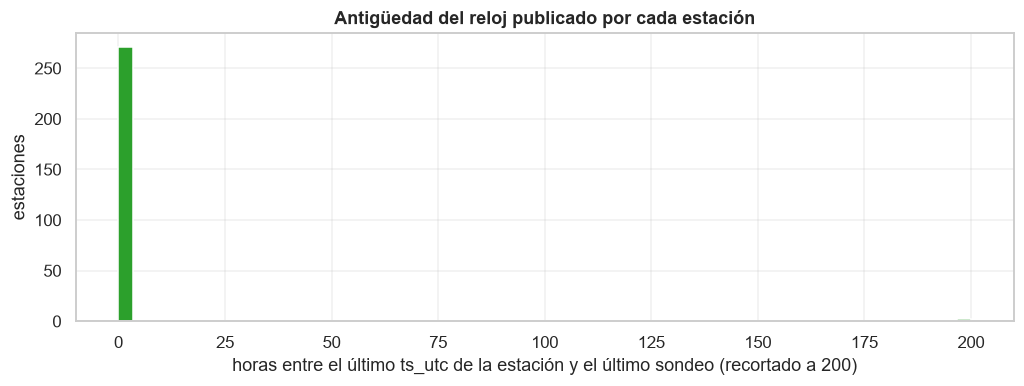

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(relojes["desfase_h"].clip(upper=200), bins=60, color=eu.PALETA[FUENTE])
ax.set_xlabel("horas entre el último ts_utc de la estación y el último sondeo (recortado a 200)")
ax.set_ylabel("estaciones")
ax.set_title("Antigüedad del reloj publicado por cada estación")
plt.show()

`ts_utc` es el reloj que publica **cada estación**, no el del sondeo. Dos de las
273 lo tienen parado: una desde el 20 de julio —casi mil horas antes del último
sondeo, de ahí el `ts_utc` mínimo de julio en un corpus que empieza el 15 de
agosto— y otra desde el 19 de agosto.

Son pocas, pero el detalle importante es que **siguen apareciendo en todos los
sondeos con el mismo contenido**: `obs` es idéntico al de las estaciones sanas. Un
modelo que mirara solo la varianza las tomaría por estaciones muy estables, que es
justo lo contrario de lo que son. Para cualquier uso temporal, `ts_ingest_utc`; y
esas estaciones son **dato ausente, no dato constante**.

## 5. Ocupación y perfil horario

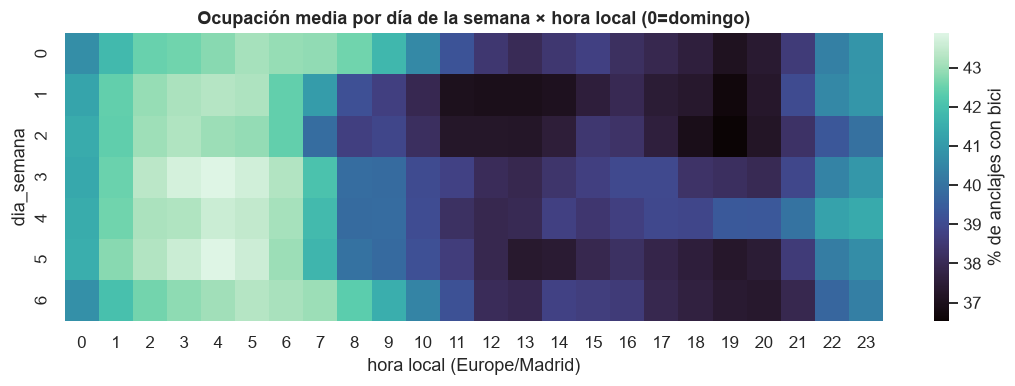

In [11]:
ocup = eu.sql(
    """
    SELECT hour(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS hora_local,
           dayofweek(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS dia_semana,
           avg(100.0 * available / nullif(available + free, 0)) AS pct_ocupacion
    FROM {f} WHERE abierta GROUP BY 1, 2
    """,
    f=FUENTE,
)
pv = ocup.pivot(index="dia_semana", columns="hora_local", values="pct_ocupacion")

fig, ax = plt.subplots(figsize=(12, 3.4))
sns.heatmap(pv, cmap="mako", ax=ax, cbar_kws={"label": "% de anclajes con bici"})
ax.set_title("Ocupación media por día de la semana × hora local (0=domingo)")
ax.set_xlabel("hora local (Europe/Madrid)")
plt.show()

In [12]:
eu.frecuencias(FUENTE, "abierta")

,valor,filas,pct,pct_acum
0,True,1148238,100.000,100.000


## 6. Distribución espacial

In [13]:
eu.bbox(FUENTE)

,con_posicion,lat_min,lat_max,lon_min,lon_max,sin_posicion
0,1148238,39.440,39.501,-0.426,-0.323,0.000


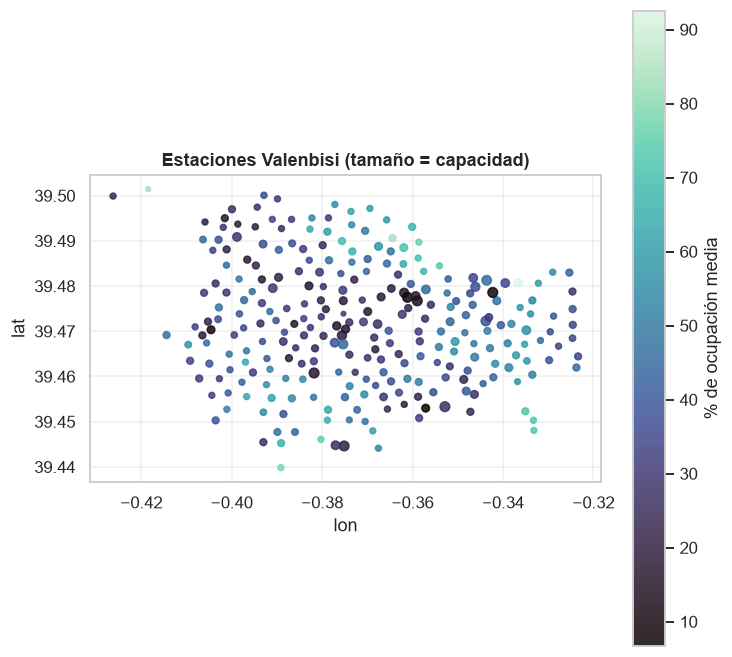

In [14]:
est = eu.sql(
    """
    SELECT number, any_value(name) AS nombre, any_value(lat) AS lat, any_value(lon) AS lon,
           avg(total) AS capacidad,
           avg(100.0 * available / nullif(available + free, 0)) AS pct_ocupacion
    FROM {f} GROUP BY 1
    """,
    f=FUENTE,
).dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(7.5, 7.5))
sc = ax.scatter(est["lon"], est["lat"], c=est["pct_ocupacion"], s=est["capacidad"], cmap="mako", alpha=0.85)
fig.colorbar(sc, ax=ax, label="% de ocupación media")
ax.set_aspect("equal")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title("Estaciones Valenbisi (tamaño = capacidad)")
plt.show()

## 7. Hallazgos

1. **`available + free` cuadra con `total` en solo tres de cada cuatro filas**, y
   el descuadre es siempre por defecto. `total` es capacidad instalada, no
   anclajes operativos. La ocupación se calcula como
   `available / (available + free)`; usar `total` mete un sesgo que cambia por
   estación y en el tiempo.
2. **Dos estaciones tienen el reloj congelado** —una desde hace más de mil
   horas— y siguen publicando filas idénticas en cada sondeo. Para el eje
   temporal, `ts_ingest_utc`; y esas estaciones son ausencia de dato, no
   estabilidad.
3. **`abierta` es constante: siempre `True`.** Nunca hay una estación cerrada en
   dieciséis días, lo que hace la columna inútil como feature y sospechosa como
   dato: probablemente la fuente no lo actualiza.
4. **La cobertura espacial es mucho menor que la de los buses.** Las estaciones
   caben en un rectángulo pequeño del centro, mientras la flota llega hasta El
   Perellonet. Como covariable solo informa del núcleo urbano, y hay que decirlo
   en vez de aplicarla a toda la red.
5. **Como covariable, el candidato razonable es la ocupación agregada por zona**,
   no la de una estación concreta: es más estable y menos sensible a estaciones
   averiadas.